Sentiment Analysis of Movie Reviews — IMDb Dataset
Deep Learning Project | TensorFlow / Keras

In [ ]:
# ── 0. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.15.0


In [ ]:
# ── 1. Config 
DATASET_DIR   = "aclImdb"          # path to extracted IMDb folder
BATCH_SIZE    = 32
SEED          = 42
MAX_TOKENS    = 10_000             # vocabulary size
SEQUENCE_LEN  = 250                # max review length (tokens)
EMBEDDING_DIM = 16
EPOCHS        = 10

# ── 2. Load Datasets 
raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
)

raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    batch_size=BATCH_SIZE,
)

print(f"\nClass names: {raw_train_ds.class_names}")   # ['neg', 'pos']

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.

Class names: ['neg', 'pos']


In [4]:
# Verify a sample batch
for text_batch, label_batch in raw_train_ds.take(1):
    print("\nSample review:", text_batch[0].numpy()[:200])
    print("Label:", label_batch[0].numpy(), "→", raw_train_ds.class_names[label_batch[0]])

# ── 3. Text Vectorisation ─────────────────────────────────────
vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LEN,
)

# Adapt ONLY on training text (no labels)
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

def vectorize_text(text, label):
    text = tf.expand_dims(text, -1)
    return vectorize_layer(text), label

train_ds  = raw_train_ds.map(vectorize_text)
val_ds    = raw_val_ds.map(vectorize_text)
test_ds   = raw_test_ds.map(vectorize_text)

# Cache + prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Sample review: b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddle'
Label: 0 → neg




In [5]:
# ── 4. Build Model ───────────────────────────────────────────
model = keras.Sequential([
    layers.Embedding(MAX_TOKENS + 1, EMBEDDING_DIM),   # token → dense vector
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),                    # average all token embeddings
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),              # binary output
])

model.summary()

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"],
)

# ── 5. Train ─────────────────────────────────────────────────
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160016    
                                                                 
 dropout (Dropout)           (None, None, 16)          0         
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                        

782/782 [==============================] - 231s 294ms/step - loss: 0.5228 - accuracy: 0.8400

Test Accuracy : 84.00%
Test Loss     : 0.5228


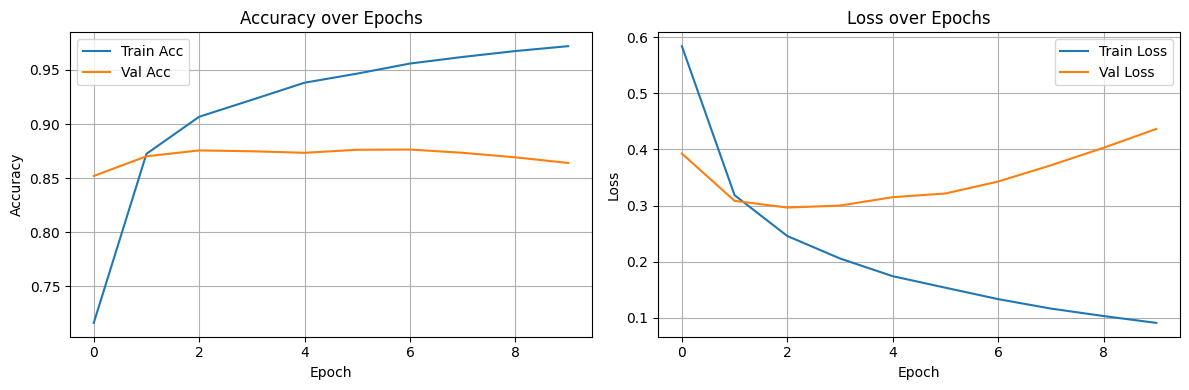

Saved: training_curves.png

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.88      0.85     12500
    Positive       0.87      0.80      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



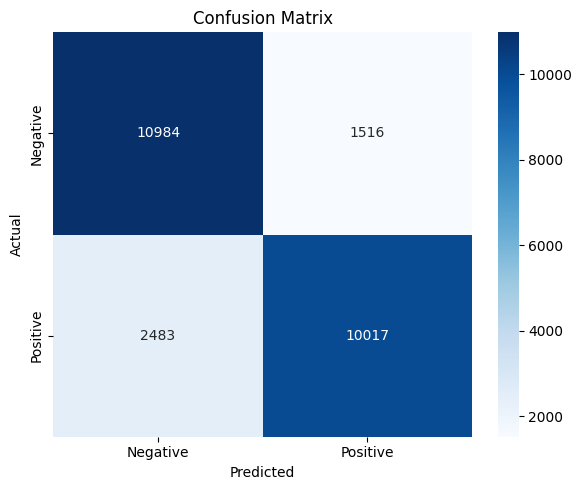

Saved: confusion_matrix.png


In [6]:
# ── 6. Evaluate ──────────────────────────────────────────────
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy : {accuracy * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

# ── 7. Training Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

# ── 8. Confusion Matrix & Classification Report ──────────────
y_true, y_pred = [], []
for text_batch, label_batch in test_ds:
    preds = model.predict(text_batch, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(label_batch.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix"); plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [7]:
# ── 9. Predict on New Reviews ────────────────────────────────
# Build an end-to-end model that includes the vectorisation layer
export_model = keras.Sequential([
    vectorize_layer,
    model,
    layers.Activation("linear"),   # no-op, keeps output as-is
])

export_model.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer="adam",
    metrics=["accuracy"],
)

sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of time. Boring and predictable.",
    "It was okay, not great but not terrible either.",
    "One of the best movies I have ever seen. Highly recommended!",
    "I couldn't even finish watching it. Very disappointing.",
]

predictions = export_model.predict(sample_reviews)
print("\n── Predictions on New Reviews ──")
for review, score in zip(sample_reviews, predictions):
    sentiment = "POSITIVE 😊" if score[0] > 0.5 else "NEGATIVE 😞"
    print(f"[{score[0]:.2f}] {sentiment} → {review[:60]}...")

# ── 10. Save Model ───────────────────────────────────────────
model.save("sentiment_model.keras")
print("\nModel saved as: sentiment_model.keras")

# To reload later:
# loaded = keras.models.load_model("sentiment_model.keras")

1/1 [==============================] - 0s 179ms/step

── Predictions on New Reviews ──
[0.55] POSITIVE 😊 → This movie was absolutely fantastic! The acting was superb....
[0.00] NEGATIVE 😞 → Terrible film. Waste of time. Boring and predictable....
[0.02] NEGATIVE 😞 → It was okay, not great but not terrible either....
[0.91] POSITIVE 😊 → One of the best movies I have ever seen. Highly recommended!...
[0.01] NEGATIVE 😞 → I couldn't even finish watching it. Very disappointing....

Model saved as: sentiment_model.keras
